<a href="https://colab.research.google.com/github/werowe/HypatiaAcademy/blob/master/ml/linear_regression_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Linear Regression




# 🎓 Predicting Student Final Scores



### Dataset
The dataset contains **500 student records** with features such as:
- `study_hours_per_week` — how many hours per week the student studies
- `attendance_rate` — percentage of classes attended
- `previous_score` — score from a prior assessment
- `extracurricular` — whether the student participates in extracurricular activities (Yes/No)
- `gender`, `age`, `parent_education`, `internet_access`
- `final_score` — **our target variable** (what we want to predict)



---
## 1. Load Libraries and Data

We start by importing **pandas**, the core Python library for working with tabular data.

- `pd.read_csv()` reads a CSV file from a URL or local path and returns a **DataFrame** — a 2D table with labeled rows and columns.
- The data is hosted publicly on GitHub, so no local file download is needed.

In [1]:
import pandas as pd  # pandas: the standard library for data manipulation in Python

# Load the student dataset from GitHub into a pandas DataFrame.
# A DataFrame is essentially a spreadsheet in Python — rows are students, columns are features.
df = pd.read_csv(
    "https://raw.githubusercontent.com/werowe/HypatiaAcademy/refs/heads/master/ml/students.csv"
)

# Quick sanity check: print the shape (rows, columns) of the dataset
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 500 rows, 11 columns


---
## 2. Explore the Data

Before building any model, we need to **understand our data**. This is called Exploratory Data Analysis (EDA).

Key questions to answer:
- What columns exist and what are their data types?
- Are there missing values?
- What does the data look like?

### 2.1 Preview the Full DataFrame

In [2]:
# Display the full DataFrame.
# In Jupyter/Colab, placing a variable on the last line of a cell renders it as a formatted HTML table.
df

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes
...,...,...,...,...,...,...,...,...,...,...,...
495,STU0496,Female,19,6,78.3,Master,No,No,51,27,No
496,STU0497,Female,16,27,61.1,PhD,No,No,47,74,Yes
497,STU0498,Female,18,16,72.3,Master,No,Yes,52,61,Yes
498,STU0499,Male,17,29,91.3,NaN,Yes,No,39,86,Yes


### 2.2 Column Data Types and Missing Values

- `df.info()` shows column names, non-null counts, and dtypes.
- Columns with fewer non-null entries than total rows have **missing values (NaN)**.
- Machine learning models cannot handle NaN values — we must deal with them before training.

In [3]:
# Show column names, data types, and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            500 non-null    object 
 1   gender                500 non-null    object 
 2   age                   500 non-null    int64  
 3   study_hours_per_week  500 non-null    int64  
 4   attendance_rate       500 non-null    float64
 5   parent_education      383 non-null    object 
 6   internet_access       500 non-null    object 
 7   extracurricular       500 non-null    object 
 8   previous_score        500 non-null    int64  
 9   final_score           500 non-null    int64  
 10  passed                500 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 43.1+ KB


In [4]:
# Statistical summary of all numeric columns
df.describe()

,age,study_hours_per_week,attendance_rate,previous_score,final_score
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,16.978000,15.312000,76.380600,62.986000,55.980000
std,1.434445,8.568167,13.817681,18.937451,15.373754
min,15.000000,2.000000,50.200000,30.000000,20.000000
25%,16.000000,8.000000,64.475000,46.000000,45.000000
50%,17.000000,15.000000,76.500000,64.000000,56.000000
75%,18.000000,23.000000,88.525000,79.000000,68.000000
max,19.000000,30.000000,100.000000,95.000000,95.000000


### 2.4 Inspect the Key Numeric Features

The three numeric features we'll use as inputs to our models are:
- `study_hours_per_week`
- `attendance_rate`
- `previous_score`

Let's look at just these columns to get a feel for the data ranges.

In [5]:
# Select and display only the three numeric feature columns.
# Double brackets [[ ]] are used to select multiple columns — the result is still a DataFrame.
df[['study_hours_per_week', 'attendance_rate', 'previous_score']]

,study_hours_per_week,attendance_rate,previous_score
0,25,63.8,41
1,2,54.7,83
2,10,90.5,73
3,26,66.8,75
4,25,73.0,67
...,...,...,...
495,6,78.3,51
496,27,61.1,47
497,16,72.3,52
498,29,91.3,39


---
## 3. Encode Categorical Variables

Machine learning models work with **numbers**, not text. Several columns in our dataset contain text categories:

| Column | Type | Example values |
|---|---|---|
| `gender` | Binary text | `'Male'`, `'Female'` |
| `extracurricular` | Binary text | `'Yes'`, `'No'` |
| `internet_access` | Binary text | `'Yes'`, `'No'` |
| `parent_education` | Multi-class text | `'Bachelor'`, `'Master'`, `'PhD'`, `'High School'` |

We need to **encode** these as numbers before feeding them to a model.

### 3.1 Encode `gender` with LabelEncoder

`LabelEncoder` assigns an integer to each unique category alphabetically:
- `'Female'` → `0`
- `'Male'` → `1`

> ⚠️ **Note:** LabelEncoder is fine for binary categories. For multi-class categories (like `parent_education`), consider using `pd.get_dummies()` (One-Hot Encoding) to avoid implying false ordering.

In [6]:
from sklearn.preprocessing import LabelEncoder  # Converts text categories to integers

# Create a LabelEncoder instance.
# It will learn the unique categories when we call fit_transform().
le = LabelEncoder()

# fit_transform() does two things in one step:
#   1. fit()      — learns the unique categories in 'gender' ('Female', 'Male')
#   2. transform() — replaces each category with its assigned integer
# We store the result in a NEW column 'gender_encoded' to preserve the original.
df['gender_encoded'] = le.fit_transform(df['gender'])

# Show the original vs encoded columns side by side to verify correctness
display(df[['gender', 'gender_encoded']].head(10))

# Show the mapping: which label maps to which integer
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

,gender,gender_encoded
0,Male,1
1,Female,0
2,Female,0
3,Male,1
4,Female,0
5,Female,0
6,Male,1
7,Female,0
8,Female,0
9,Female,0


Label mapping: {'Female': np.int64(0), 'Male': np.int64(1)}


### 3.2 Encode `extracurricular` with `.map()`

For simple Yes/No columns, we can use pandas `.map()` with a dictionary instead of LabelEncoder — it's more explicit and readable:
- `'Yes'` → `1`
- `'No'`  → `0`

After mapping, any values that weren't `'Yes'` or `'No'` (e.g., missing values) become `NaN`.
We fill those with the **mode** (most common value) so we don't lose rows.

Let's first peek at the column before encoding:

In [7]:
# Display unique values and counts in the extracurricular column before encoding
print("Unique values in 'extracurricular':")
print(df['extracurricular'].value_counts())
print(f"\nMissing values: {df['extracurricular'].isnull().sum()}")

Unique values in 'extracurricular':
extracurricular
No     253
Yes    247
Name: count, dtype: int64

Missing values: 0


In [8]:
# Convert 'extracurricular' from text ('Yes'/'No') to numeric (1/0).
# .map() replaces each value using the provided dictionary.
# Any value NOT in the dictionary (e.g., NaN or unexpected strings) becomes NaN.
df['extracurricular'] = df['extracurricular'].map({'Yes': 1, 'No': 0})

# Handle any NaN values that resulted from missing or unexpected entries.
# Strategy: fill with the MODE (most frequent value — either 0 or 1).
if df['extracurricular'].isnull().all():
    # Edge case: if ALL values are NaN, mode() returns empty — fall back to 0
    fill_value = 0
else:
    # mode() returns a Series; [0] gets the first (most common) value
    fill_value = df['extracurricular'].mode()[0]

df['extracurricular'] = df['extracurricular'].fillna(fill_value)

print(f"Encoding complete. Fill value used for NaNs: {fill_value}")
print(f"Value counts after encoding:\n{df['extracurricular'].value_counts()}")

Encoding complete. Fill value used for NaNs: 0
Value counts after encoding:
extracurricular
0    253
1    247
Name: count, dtype: int64


---
## 4. Random Forest Regressor

### What is a Random Forest?

A **Random Forest** is an **ensemble model** — it builds many individual Decision Trees and averages their predictions.

```
Input Features
     │
     ├──► Tree 1 ──► prediction₁ ┐
     ├──► Tree 2 ──► prediction₂ ├──► Average ──► Final Prediction
     ├──► Tree 3 ──► prediction₃ ┘
     └──► ... (100 trees total)
```

**Why use Random Forest?**
- Handles non-linear relationships automatically
- Robust to outliers
- Less prone to overfitting than a single Decision Tree
- Works well without much feature scaling

**Features used:** `study_hours_per_week`, `attendance_rate`, `previous_score`

**Target:** `final_score`

### 4.1 Prepare Features and Target

In [9]:
from sklearn.model_selection import train_test_split   # Splits data into training and test sets
from sklearn.ensemble import RandomForestRegressor     # The Random Forest model for regression
from sklearn.metrics import r2_score, mean_absolute_error  # Evaluation metrics

# --- Define Feature Matrix (X) ---
# X contains the INPUT columns — the data the model uses to make predictions.
# These are called 'independent variables' or 'features'.
X_rf = df[['study_hours_per_week', 'attendance_rate', 'previous_score']]

# --- Define Target Vector (y) ---
# y contains the OUTPUT column — what we want the model to learn to predict.
# This is called the 'dependent variable' or 'target'.
y = df['final_score']

print(f"Feature matrix shape: {X_rf.shape}  → {X_rf.shape[0]} samples, {X_rf.shape[1]} features")
print(f"Target vector shape:  {y.shape}")

Feature matrix shape: (500, 3)  → 500 samples, 3 features
Target vector shape:  (500,)


### 4.2 Train/Test Split

We split the data into two separate sets:

| Set | Size | Purpose |
|---|---|---|
| **Training set** | 80% (400 rows) | The model learns patterns from this data |
| **Test set** | 20% (100 rows) | We evaluate accuracy on data the model has never seen |

Why split? If we trained and tested on the **same data**, the model could just memorize it and score 100% — but fail on new data. The test set simulates real-world, unseen data.

> `random_state=42` is a seed that makes the split reproducible — you'll get the same split every time you run the notebook.

In [10]:
# Split the data: 80% for training, 20% for testing.
# random_state=42 ensures the same split every run (reproducibility).
X_train_rf, X_test_rf, y_train, y_test = train_test_split(
    X_rf, y,
    test_size=0.2,      # 20% of data goes to the test set
    random_state=42     # seed for reproducibility
)

print(f"Training set: {X_train_rf.shape[0]} samples")
print(f"Test set:     {X_test_rf.shape[0]} samples")

Training set: 400 samples
Test set:     100 samples


### 4.3 Train and Predict

Training a model in scikit-learn always follows the same three-step pattern:

```python
model = ModelClass(hyperparameters)   # 1. Create the model
model.fit(X_train, y_train)           # 2. Train it on the training data
preds = model.predict(X_test)         # 3. Generate predictions on the test data
```

**Hyperparameters** are settings you choose before training. For `RandomForestRegressor`:
- `n_estimators=100` — build 100 trees (more trees = more stable, but slower)
- `random_state=42` — ensures reproducible tree building

In [11]:
# Step 1: Create the Random Forest model with 100 decision trees
rf_model = RandomForestRegressor(
    n_estimators=100,   # Number of trees in the forest
    random_state=42     # Seed for reproducibility
)

# Step 2: Train (fit) the model on the training data.
# The model learns which feature combinations lead to which final_score values.
rf_model.fit(X_train_rf, y_train)

# Step 3: Predict final scores for the test set.
# The model has never seen X_test_rf before — these are genuinely new predictions.
preds_rf = rf_model.predict(X_test_rf)

print("Random Forest predictions (first 10):")
print(preds_rf[:10].round(2))

Random Forest predictions (first 10):
[56.8  81.55 31.34 58.89 63.21 65.6  52.61 27.25 64.37 36.7 ]


---
## 6. Evaluating Model Performance: R² Score

### What is R² (R-squared)?

**R²** (the coefficient of determination) measures **how well the model explains the variance in the target variable**.

| R² value | Interpretation |
|---|---|
| `1.0` | Perfect fit — model predicts every value exactly |
| `0.7` | Model explains 70% of the variance in final scores |
| `0.0` | Model is no better than just predicting the mean every time |
| `< 0` | Model is **worse** than predicting the mean (bad model) |

### The Formula

$$
R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}
$$

Where:
- $\text{SS}_{\text{res}} = \sum (y_i - \hat{y}_i)^2$ — **Sum of Squared Residuals**: total prediction error
- $\text{SS}_{\text{tot}} = \sum (y_i - \bar{y})^2$ — **Total Sum of Squares**: total variance in the data
- $y_i$ = actual values, $\hat{y}_i$ = predicted values, $\bar{y}$ = mean of actual values

**Intuition:** R² compares your model's errors against a naive baseline that just predicts the average every time. If your model's errors are much smaller than the baseline, R² is close to 1.

### 6.1 Compute R² Using scikit-learn

In [12]:
# sklearn provides r2_score() to compute R² in one line.
# It takes the actual values (y_test) and the model's predictions.

r2_rf = r2_score(y_test, preds_rf)

print(f"Random Forest R²:   {r2_rf:.4f}  ({r2_rf*100:.1f}% of variance explained)")


Random Forest R²:   0.6773  (67.7% of variance explained)


---
## 7. Visualise: Actual vs Predicted Scores

A scatter plot of **actual vs predicted values** is a standard way to visually evaluate a regression model.

- **Perfect model** → all points lie on a diagonal line (y = x)
- **Good model** → points cluster tightly around the diagonal
- **Poor model** → points are scattered randomly

We'll plot both models side by side for easy comparison.

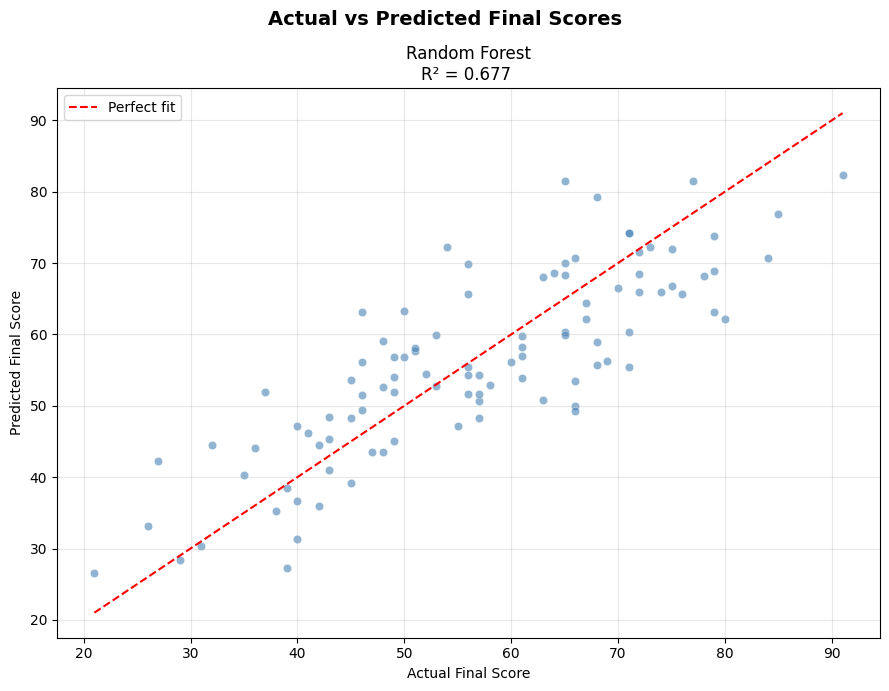

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Create one plot
fig, ax1 = plt.subplots(1, 1, figsize=(9, 7))

# Plot: Random Forest
ax1.scatter(
    y_test,
    preds_rf,
    alpha=0.6,
    color='steelblue',
    edgecolors='white',
    linewidth=0.4
)

# Add perfect-prediction diagonal line
min_val = min(y_test.min(), preds_rf.min())
max_val = max(y_test.max(), preds_rf.max())

ax1.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=1.5,
    label='Perfect fit'
)

ax1.set_xlabel('Actual Final Score')
ax1.set_ylabel('Predicted Final Score')
ax1.set_title(f'Random Forest\nR² = {r2_rf:.3f} ')
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted Final Scores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Feature Importance (Random Forest)

One advantage of Random Forests over Linear Regression is that they provide **feature importances** — a measure of how much each input feature contributed to the model's predictions.

Values sum to 1.0. A higher value means the feature was more influential.

Feature Importances (Random Forest):
             Feature  Importance
study_hours_per_week    0.708799
     attendance_rate    0.153249
      previous_score    0.137952


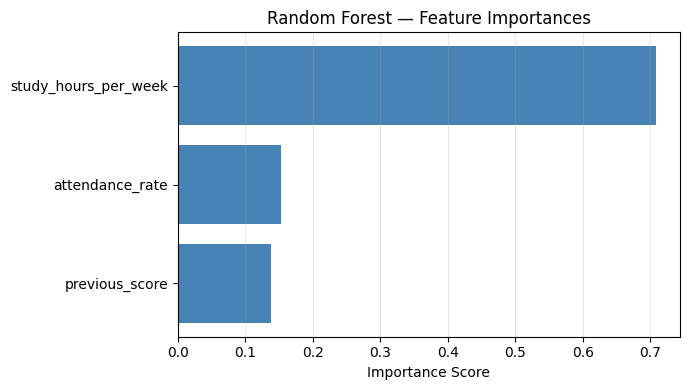

In [14]:
# Extract feature importances from the trained Random Forest model
importances = rf_model.feature_importances_
feature_names = X_rf.columns.tolist()

# Build a sorted DataFrame for easy reading
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Feature Importances (Random Forest):")
print(importance_df.to_string(index=False))

# Visualise as a bar chart
plt.figure(figsize=(7, 4))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Random Forest — Feature Importances')
plt.gca().invert_yaxis()  # Most important at the top
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()